# SJT DBSCAN

In [3]:
import sys
import os
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from pandas import Timedelta
from sklearn import metrics
import datetime

In [4]:
df = pd.read_csv('../csv/preprocessed_data.csv')
df_cand = pd.read_csv('../../../decoded_data/DimCandidate.csv')
df = df.set_index(['TestKey'])
df

,Q0_A1,Q0_A2,Q0_A3,Q1_A1,Q1_A2,Q1_A3,Q2_A1,Q2_A2,Q2_A3,Q3_A1,...,Q11_A3,Q12_A1,Q12_A2,Q12_A3,Q13_A1,Q13_A2,Q13_A3,Year,Month,Day
TestKey,,,,,,,,,,,,,,,,,,,,,
160068,0.0,0.0,0.0,5.0,4.0,2.0,4.0,3.0,2.0,4.0,...,5.0,3.0,5.0,4.0,4.0,3.0,2.0,2023,11,2
160069,0.0,0.0,0.0,2.0,4.0,5.0,4.0,3.0,5.0,5.0,...,5.0,4.0,5.0,2.0,3.0,4.0,2.0,2023,12,3
160070,0.0,0.0,0.0,3.0,5.0,1.0,1.0,3.0,4.0,1.0,...,5.0,4.0,3.0,2.0,4.0,1.0,5.0,2017,12,3
160071,0.0,0.0,0.0,2.0,4.0,3.0,4.0,5.0,2.0,3.0,...,4.0,3.0,4.0,5.0,5.0,2.0,4.0,2018,10,1
160072,0.0,0.0,0.0,4.0,2.0,3.0,4.0,1.0,2.0,2.0,...,4.0,4.0,2.0,3.0,2.0,3.0,5.0,2023,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166957,0.0,0.0,0.0,3.0,4.0,1.0,5.0,3.0,4.0,2.0,...,4.0,5.0,4.0,3.0,5.0,4.0,3.0,2024,7,2
166958,0.0,0.0,0.0,5.0,4.0,3.0,3.0,4.0,2.0,1.0,...,5.0,3.0,5.0,1.0,5.0,1.0,2.0,2024,7,2
166959,0.0,0.0,0.0,5.0,1.0,3.0,2.0,3.0,5.0,1.0,...,5.0,2.0,5.0,4.0,5.0,4.0,3.0,2024,7,2


In [5]:
df.drop(columns=['Year','Month','Day'],inplace=True)

<Axes: xlabel='x', ylabel='y'>

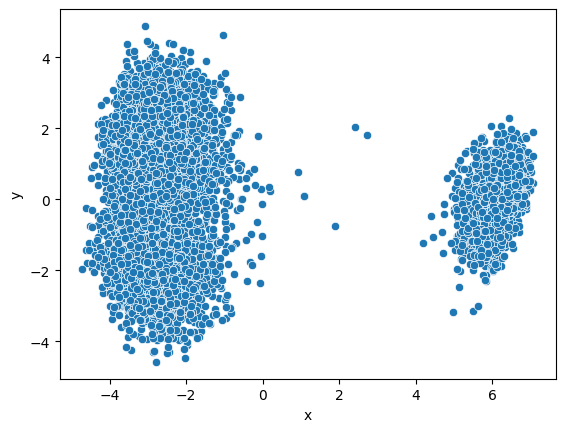

In [6]:
sc = StandardScaler()
df_scaled = pd.DataFrame(sc.fit_transform(df),index=df.index,columns=df.columns)
df_scaled.fillna(0, inplace=True)
df_for_pca = df_scaled
pca = PCA(n_components=2)
df_pca2 = pd.DataFrame(pca.fit_transform(df_for_pca), index=df_for_pca.index,columns=['x','y'])
sns.scatterplot(df_pca2,x=df_pca2.x,y=df_pca2.y)

In [7]:
def GridSearchDBScan(min_samples_values,eps_values):
  min_samples_values = min_samples_values
  eps_values = eps_values
  results = []
  for min_samples in min_samples_values:
      for eps in eps_values:
        try:   
            startTime = datetime.datetime.now()
            print(f"Trying min_samples {min_samples} and eps {eps}")
            # Create and fit DBSCAN model
            dbscan = DBSCAN(min_samples=min_samples, eps=eps)
            dbscan.fit(df_scaled)
            labels = dbscan.labels_

            if len(set(labels)) > 1:
                silhouette_avg = metrics.silhouette_score(df_scaled, labels)
            else:
                silhouette_avg = -1
            
            duration = Timedelta(datetime.datetime.now()-startTime)
            print(f"Silhouette ({min_samples,eps}): {silhouette_avg}")
            print(f"Duration: {duration}")
            results.append({
                'min_samples': min_samples,
                'eps': eps,
                'silhouette_score': silhouette_avg,
                'num_clusters': len(set(labels)) - (1 if -1 in labels else 0),
                'num_noise': list(labels).count(-1)
            })
        except Exception as error:
           print(error)
  return results

results = GridSearchDBScan(min_samples_values=[3, 5, 10, 20, 50],eps_values=[0.01,0.05,0.5,2,5])


Trying min_samples 3 and eps 0.01
Silhouette ((3, 0.01)): -0.022639199784147326
Duration: 0 days 00:00:01.211479
Trying min_samples 3 and eps 0.05
Silhouette ((3, 0.05)): -0.022639199784147326
Duration: 0 days 00:00:01.070717
Trying min_samples 3 and eps 0.5
Silhouette ((3, 0.5)): -0.022639199784147326
Duration: 0 days 00:00:01.059849
Trying min_samples 3 and eps 2
Silhouette ((3, 2)): -0.1813580925669113
Duration: 0 days 00:00:00.929899
Trying min_samples 3 and eps 5
Silhouette ((3, 5)): 0.29224557829948455
Duration: 0 days 00:00:00.836136
Trying min_samples 5 and eps 0.01
Silhouette ((5, 0.01)): -1
Duration: 0 days 00:00:00.079078
Trying min_samples 5 and eps 0.05
Silhouette ((5, 0.05)): -1
Duration: 0 days 00:00:00.069602
Trying min_samples 5 and eps 0.5
Silhouette ((5, 0.5)): -1
Duration: 0 days 00:00:00.066873
Trying min_samples 5 and eps 2
Silhouette ((5, 2)): 0.01590450419389497
Duration: 0 days 00:00:00.774576
Trying min_samples 5 and eps 5
Silhouette ((5, 5)): 0.29003529954058

In [8]:
best_dbscan = DBSCAN(min_samples=10,eps=5)
best_dbscan.fit(df_scaled)
values, counts = np.unique(best_dbscan.labels_,return_counts=True)
counts[1:].sum()

6738

In [9]:
counts

array([ 156, 4617, 2121], dtype=int64)

In [10]:
values

array([-1,  0,  1], dtype=int64)

In [11]:
labels = pd.DataFrame(best_dbscan.labels_,index=df.index, columns=['label'])
labels

,label
TestKey,
160068,0
160069,0
160070,0
160071,0
160072,0
...,...
166957,0
166958,0
166959,0


In [12]:
dbscan_anom = labels[labels.label==-1]

In [13]:
anomalies2d = df_pca2.loc[dbscan_anom.index]

<Axes: xlabel='x', ylabel='y'>

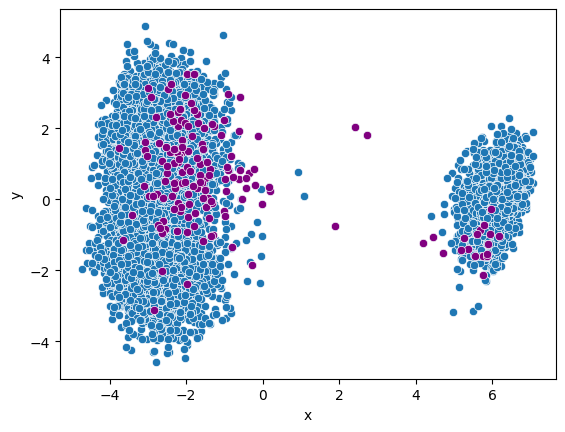

In [14]:
sns.scatterplot(df_pca2,x=df_pca2.x,y=df_pca2.y)
sns.scatterplot(anomalies2d,x=anomalies2d.x,y=anomalies2d.y,color="purple")

In [15]:
labels['is_anomaly'] = labels[['label']].map(lambda label : 1 if label==-1 else 0)
labels.drop(columns=['label'],inplace=True)

In [16]:
os.chdir('..')
csv_path = os.path.join("csv")
os.chdir(csv_path)
labels.to_csv('dbscan_anomalies.csv')